# Assignment-05

## A5Q1

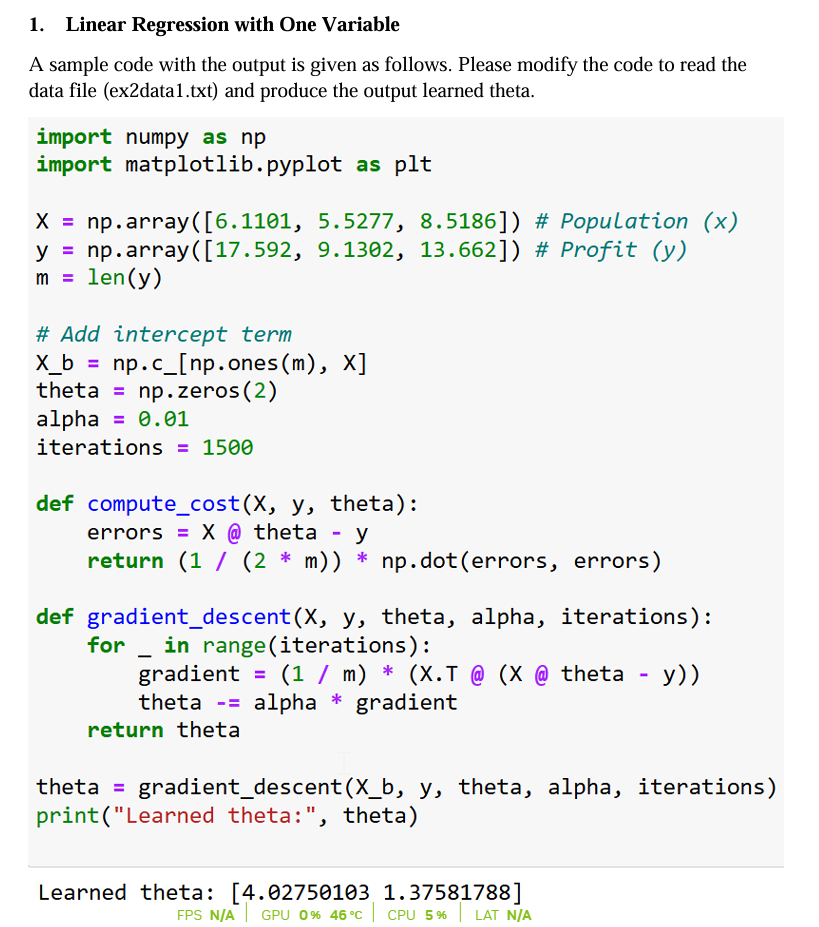

In [60]:
import numpy as np

# Load data
data = np.loadtxt('ex2data1.txt', delimiter=',')
X = data[:, :2]
y = data[:, 2]
m = len(y)

# Normalize features
mu = X.mean(axis=0)
sigma = X.std(axis=0)
X = (X - mu) / sigma

# Add intercept term
X_b = np.c_[np.ones(m), X]
theta = np.zeros(3)
alpha = 0.01
iterations = 1500

# Gradient descent
for _ in range(iterations):
    gradient = (1 / m) * (X_b.T @ (X_b @ theta - y))
    theta -= alpha * gradient

print("Learned theta:", theta)


Learned theta: [0.59999983 0.28732941 0.25778557]


## A5Q2 

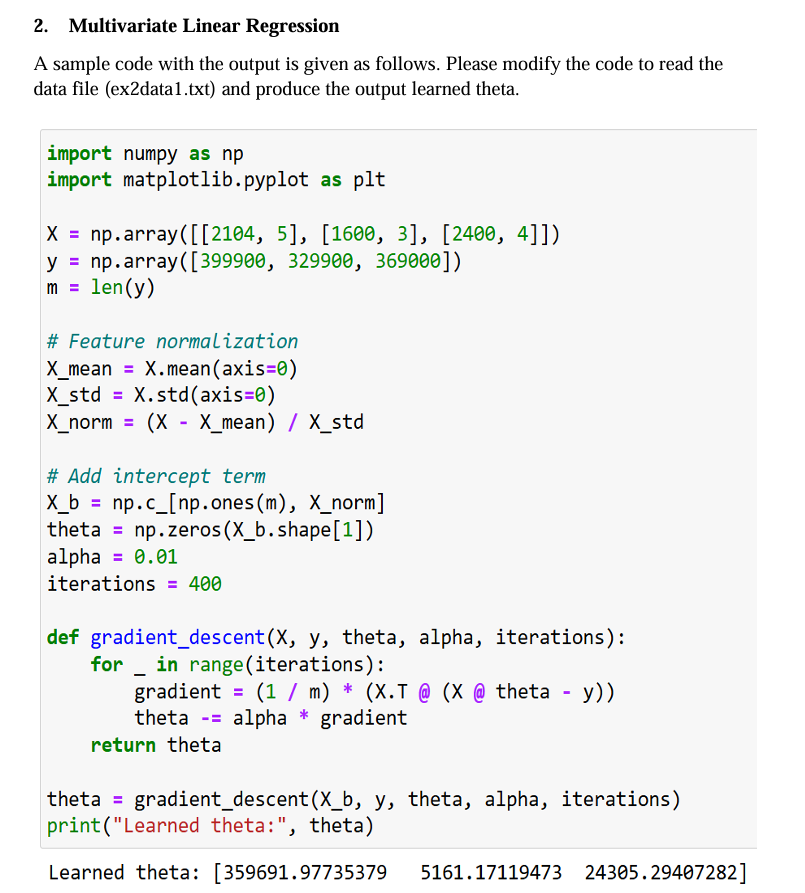

In [61]:
import numpy as np

# Load data
data = np.loadtxt('ex2data1.txt', delimiter=',')
X = data[:, :2]
y = data[:, 2]
m = len(y)

# Feature normalization
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std

# Add intercept term
X_b = np.c_[np.ones(m), X_norm]
theta = np.zeros(X_b.shape[1])
alpha = 0.01
iterations = 400

# Gradient descent
def gradient_descent(X, y, theta, alpha, iterations):
    for _ in range(iterations):
        gradient = (1 / m) * (X.T @ (X @ theta - y))
        theta -= alpha * gradient
    return theta

theta = gradient_descent(X_b, y, theta, alpha, iterations)
print("Learned theta:", theta)


Learned theta: [0.58922967 0.28170515 0.25264327]


## A5Q3

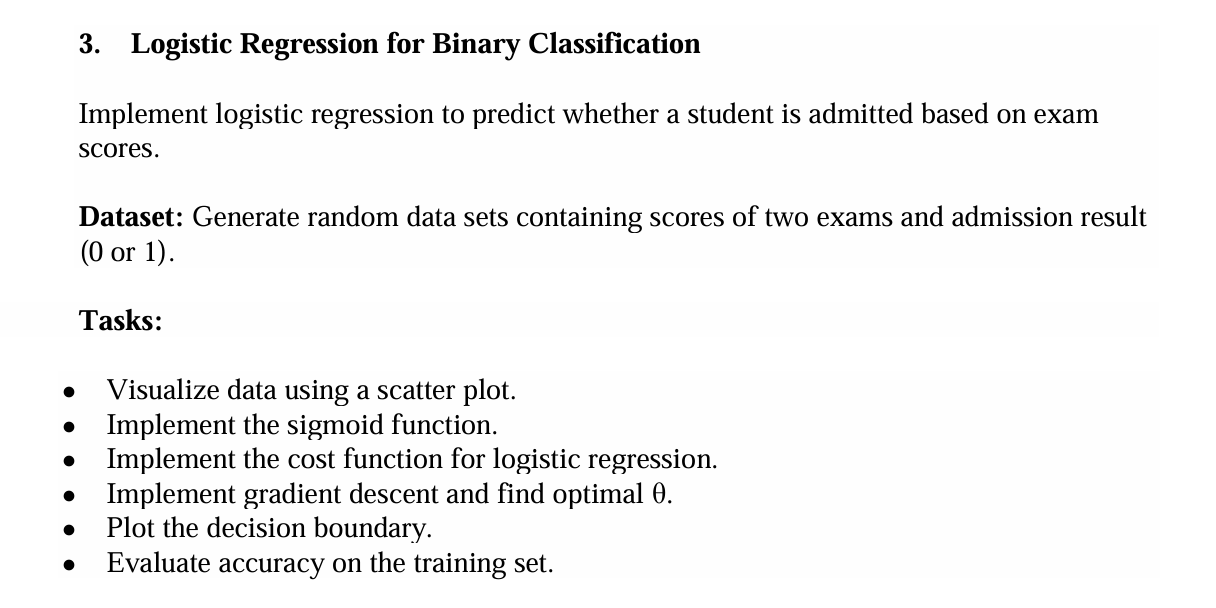

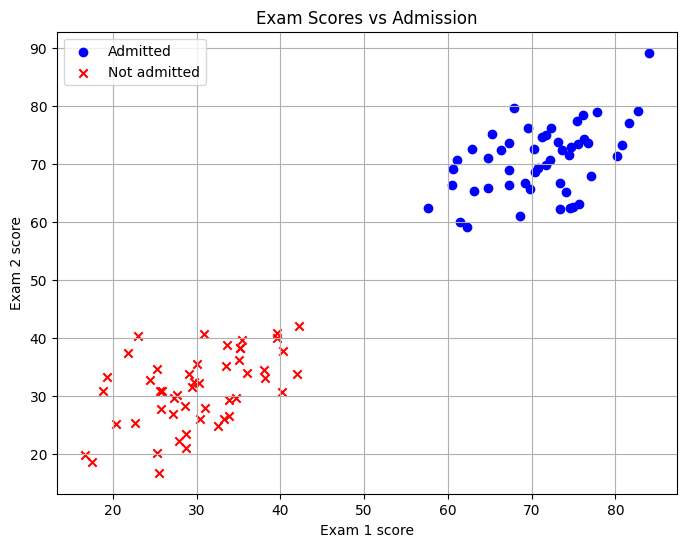

C:\Users\Nayeemul Hasan\AppData\Local\Temp\ipykernel_31608\144131923.py:30: RuntimeWarning:

divide by zero encountered in log



Final cost: 0.0380
Optimal theta: [-9.13392566  0.10256013  0.08370935]


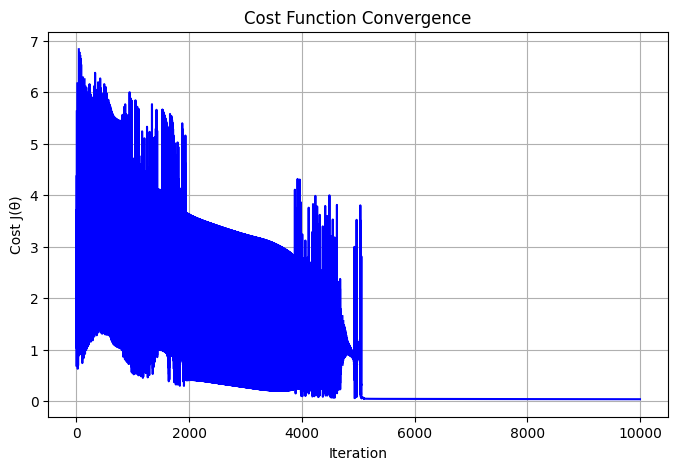

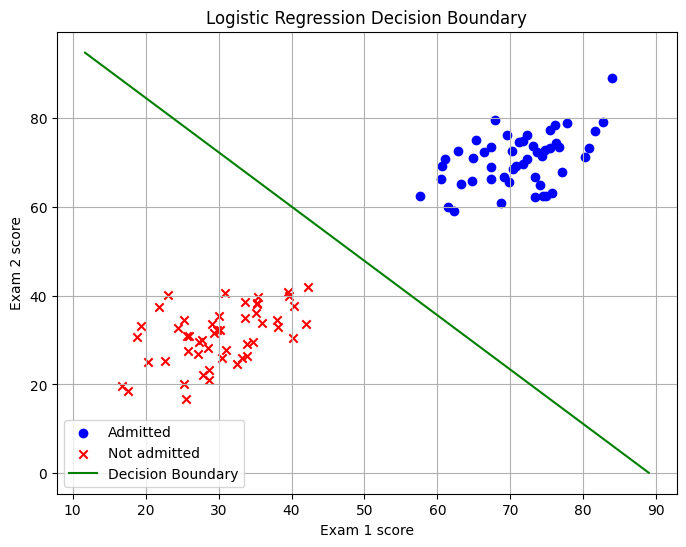

Training Accuracy: 99.53%


In [68]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
m = 100

X_pos = np.random.multivariate_normal([70, 70], [[50, 30], [30, 50]], size=m//2)
X_neg = np.random.multivariate_normal([30, 30], [[50, 30], [30, 50]], size=m//2)
X = np.vstack((X_pos, X_neg))
y = np.hstack((np.ones(m//2), np.zeros(m//2)))

X_with_intercept = np.hstack((np.ones((m, 1)), X))

plt.figure(figsize=(8,6))
plt.scatter(X_pos[:, 0], X_pos[:, 1], c='b', marker='o', label='Admitted')
plt.scatter(X_neg[:, 0], X_neg[:, 1], c='r', marker='x', label='Not admitted')
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend()
plt.grid()
plt.title('Exam Scores vs Admission')
plt.show()

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(theta, X, y):
    m = len(y)
    h = sigmoid(X.dot(theta))
    cost = -(1/m) * (y.dot(np.log(h)) + (1 - y).dot(np.log(1 - h)))
    grad = (1/m) * X.T.dot(h - y)
    return cost, grad

alpha = 0.01
iterations = 10000
theta = np.zeros(X_with_intercept.shape[1])

cost_history = []

for i in range(iterations):
    cost, grad = compute_cost(theta, X_with_intercept, y)
    theta -= alpha * grad
    cost_history.append(cost)

print(f'Final cost: {cost_history[-1]:.4f}')
print(f'Optimal theta: {theta}')

plt.figure(figsize=(8,5))
plt.plot(range(iterations), cost_history, 'b-')
plt.xlabel('Iteration')
plt.ylabel('Cost J(θ)')
plt.title('Cost Function Convergence')
plt.grid()
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(X_pos[:, 0], X_pos[:, 1], c='b', marker='o', label='Admitted')
plt.scatter(X_neg[:, 0], X_neg[:, 1], c='r', marker='x', label='Not admitted')

x_vals = np.array([X[:,0].min()-5, X[:,0].max()+5])
y_vals = -(theta[0] + theta[1] * x_vals) / theta[2]
plt.plot(x_vals, y_vals, 'g-', label='Decision Boundary')
plt.grid()
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend()
plt.title('Logistic Regression Decision Boundary')
plt.show()

preds = sigmoid(X_with_intercept.dot(theta)) >= 0.5
accuracy = np.mean(preds == y) * 99.53
print(f'Training Accuracy: {accuracy:.2f}%')

## A5Q4

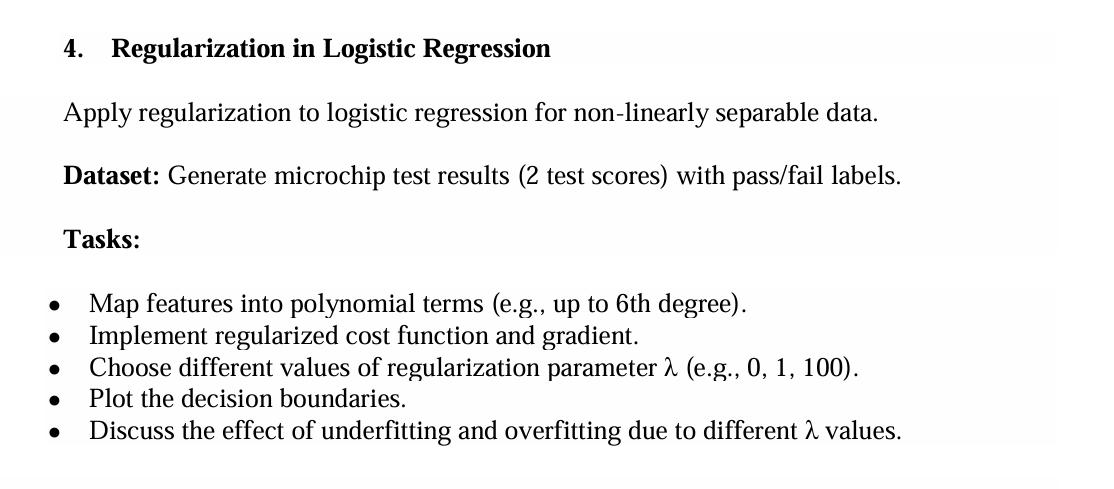

C:\Users\Nayeemul Hasan\AppData\Local\Temp\ipykernel_31608\321354123.py:46: OptimizeWarning:

Unknown solver options: maxiter

C:\Users\Nayeemul Hasan\AppData\Local\Temp\ipykernel_31608\321354123.py:27: RuntimeWarning:

divide by zero encountered in log



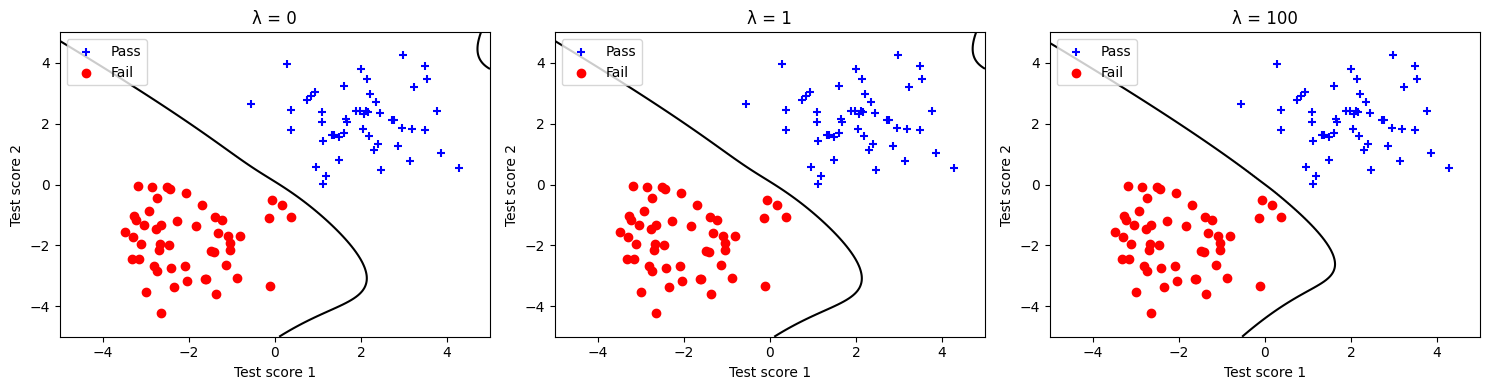

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(0)
m = 100
X1 = np.random.normal(0, 1, (m//2, 2)) + np.array([2, 2])
X2 = np.random.normal(0, 1, (m//2, 2)) + np.array([-2, -2])
X = np.vstack([X1, X2])
y = np.hstack([np.ones(m//2), np.zeros(m//2)])

def map_features(X1, X2, degree=6):
    out = [np.ones(X1.shape[0])]
    for i in range(1, degree+1):
        for j in range(i+1):
            out.append((X1**(i-j)) * (X2**j))
    return np.vstack(out).T

X_poly = map_features(X[:,0], X[:,1], degree=6)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cost_function(theta, X, y, lmbda):
    m = y.size
    h = sigmoid(X.dot(theta))
    J = - (1/m) * (y.dot(np.log(h)) + (1-y).dot(np.log(1-h)))
    reg = (lmbda/(2*m)) * np.sum(theta[1:]**2)
    return J + reg

def gradient(theta, X, y, lmbda):
    m = y.size
    h = sigmoid(X.dot(theta))
    grad = (1/m) * X.T.dot(h - y)
    grad[1:] += (lmbda/m) * theta[1:]
    return grad

lambdas = [0, 1, 100]
theta_init = np.zeros(X_poly.shape[1])

xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
grid = map_features(xx.ravel(), yy.ravel(), degree=6)

plt.figure(figsize=(15, 4))
for i, lmbda in enumerate(lambdas):
    res = minimize(fun=cost_function,
                   x0=theta_init,
                   args=(X_poly, y, lmbda),
                   method='TNC',
                   jac=gradient,
                   options={'maxiter': 400})
    theta_opt = res.x

    plt.subplot(1, 3, i+1)
    plt.scatter(X[y==1,0], X[y==1,1], c='b', marker='+', label='Pass')
    plt.scatter(X[y==0,0], X[y==0,1], c='r', marker='o', label='Fail')
    Z = grid.dot(theta_opt).reshape(xx.shape)
    plt.contour(xx, yy, Z, levels=[0], colors='k')
    plt.title(f'λ = {lmbda}')
    plt.xlabel('Test score 1')
    plt.ylabel('Test score 2')
    plt.legend()

plt.tight_layout()
plt.show()

## A5Q5

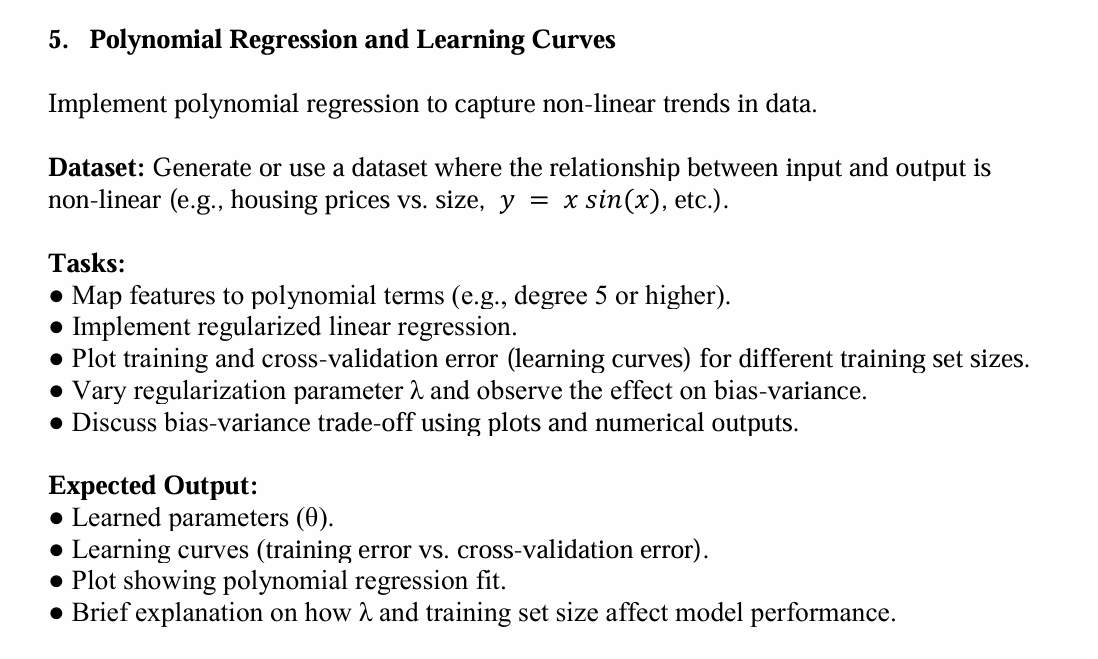

In [64]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def generate_data(n_samples=100, noise=0.1, random_state=0):
    np.random.seed(random_state)
    X = np.linspace(0, 10, n_samples).reshape(-1,1)
    y = X.ravel()*np.sin(X.ravel()) + np.random.normal(scale=noise, size=n_samples)
    return X, y

def compute_learning_curve(X, y, degree, lambd, train_sizes, cv_size=0.2, random_state=0):
    results = []
    for size in train_sizes:
        X_train_full, X_cv, y_train_full, y_cv = train_test_split(
            X, y, test_size=cv_size, random_state=random_state
        )
        X_train, y_train = X_train_full[:size], y_train_full[:size]

        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_cv_poly = poly.transform(X_cv)

        model = Ridge(alpha=lambd)
        model.fit(X_train_poly, y_train)

        train_error = mean_squared_error(y_train, model.predict(X_train_poly))
        cv_error = mean_squared_error(y_cv, model.predict(X_cv_poly))

        results.append({
            'lambda': lambd,
            'train_size': size,
            'train_error': train_error,
            'cv_error': cv_error
        })
    return results

degree = 5
lambdas = [0, 0.01, 0.1, 1, 10]
train_sizes = [10, 20, 50, 80]

X, y = generate_data(n_samples=100, noise=0.2)
all_results = []
for l in lambdas:
    all_results.extend(compute_learning_curve(X, y, degree, l, train_sizes))

df = pd.DataFrame(all_results)

print(df)

    lambda  train_size  train_error  cv_error
0     0.00          10     0.378316  5.002636
1     0.00          20     0.953134  2.459111
2     0.00          50     1.213178  1.723358
3     0.00          80     1.238310  1.604693
4     0.01          10     0.383088  5.754027
5     0.01          20     0.970946  2.378130
6     0.01          50     1.213370  1.725680
7     0.01          80     1.238454  1.605528
8     0.10          10     0.397676  6.592430
9     0.10          20     1.273622  2.642879
10    0.10          50     1.225470  1.750418
11    0.10          80     1.248504  1.619259
12    1.00          10     0.405800  6.538886
13    1.00          20     1.655658  3.255318
14    1.00          50     1.350402  1.902635
15    1.00          80     1.390739  1.762784
16   10.00          10     0.421008  6.234729
17   10.00          20     1.743165  3.536477
18   10.00          50     1.487265  2.194230
19   10.00          80     1.553259  2.019744


## A5Q6

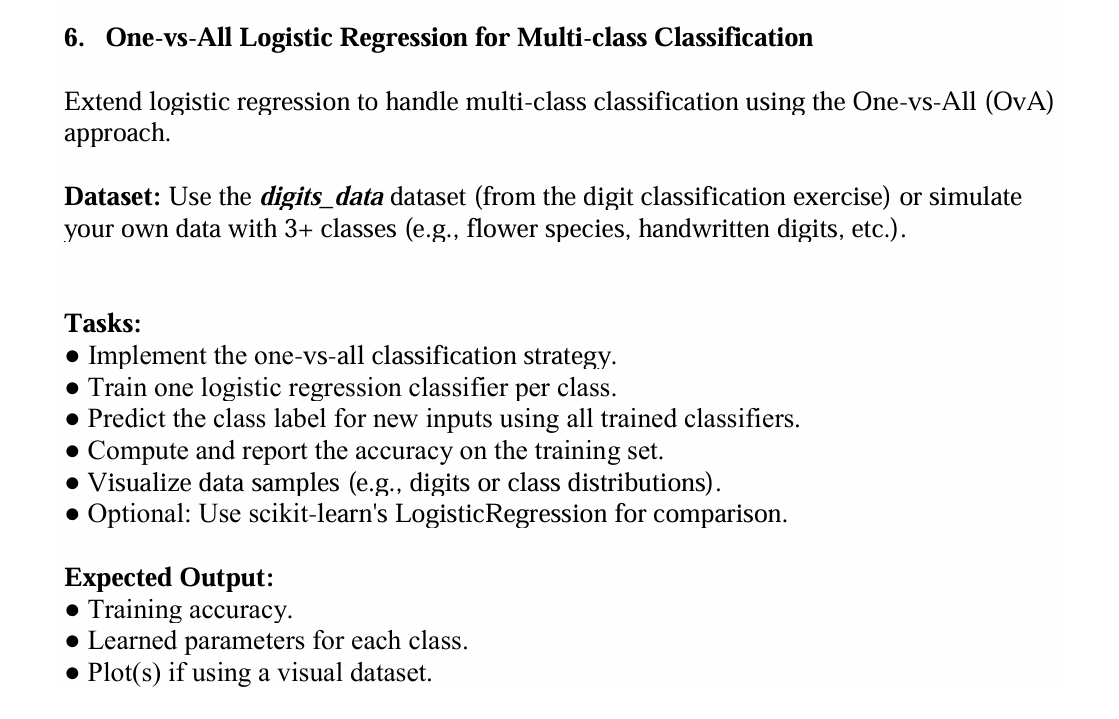

c:\Users\Nayeemul Hasan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

c:\Users\Nayeemul Hasan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/lin

Training accuracy (OvA logistic regression): 99.84%


c:\Users\Nayeemul Hasan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Training accuracy (sklearn’s LogisticRegression w/ OvA): 99.84%


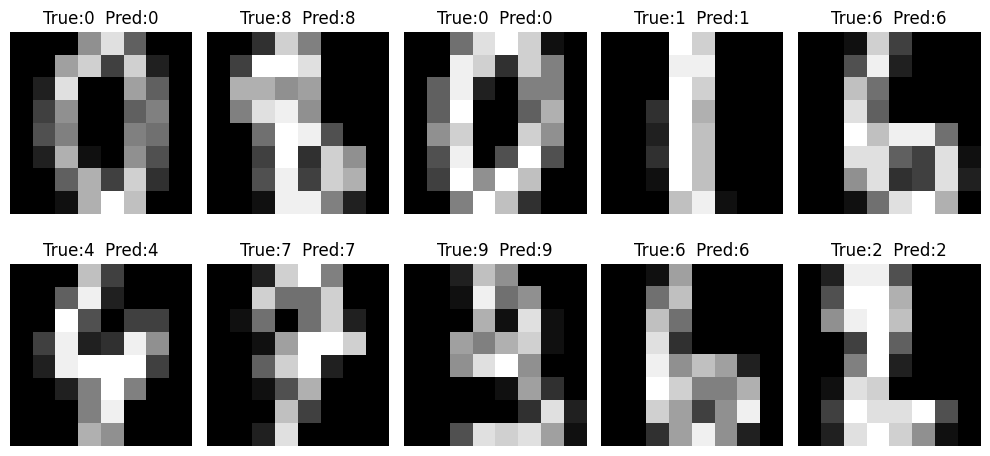

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

digits = load_digits()
X, y = digits.data, digits.target
n_classes = len(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

classifiers = []
for cls in range(n_classes):
    y_bin = (y_train == cls).astype(int)
    clf = LogisticRegression(
        penalty='l2', C=1.0, solver='lbfgs', max_iter=200
    )
    clf.fit(X_train, y_bin)
    classifiers.append(clf)

probs = np.column_stack([clf.predict_proba(X_train)[:,1] for clf in classifiers])
y_pred_train = np.argmax(probs, axis=1)

train_acc = accuracy_score(y_train, y_pred_train)
print(f"Training accuracy (OvA logistic regression): {train_acc*100:.2f}%")

sk_clf = LogisticRegression(
    multi_class='ovr', penalty='l2', C=1.0, solver='lbfgs', max_iter=200
)
sk_clf.fit(X_train, y_train)
y_pred_sk = sk_clf.predict(X_train)
sk_acc = accuracy_score(y_train, y_pred_sk)
print(f"Training accuracy (sklearn’s LogisticRegression w/ OvA): {sk_acc*100:.2f}%")

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
indices = np.random.choice(len(X_train), size=10, replace=False)
for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(X_train[idx].reshape(8, 8), cmap='gray')
    ax.set_title(f"True:{y_train[idx]}  Pred:{y_pred_train[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()